# **STORE TRIAL PERFORMANCE ANALYSIS**

## **Import Libraries**

In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

pd.set_option('display.max_columns', None)

## **Load Data**

In [185]:
df = pd.read_csv(r"C:\Users\ACM\Documents\GitHub\Quantium\Retail Data Analysis\Data\Retail Data Analysis.csv")

print(df.shape)
df.head()

(264833, 13)


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER,PRICE_PER_UNIT
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175.0,Natural,YOUNG SINGLES/COUPLES,Premium,3.00
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175.0,CCs,MIDAGE SINGLES/COUPLES,Budget,2.10
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170.0,Smiths,MIDAGE SINGLES/COUPLES,Budget,1.45
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175.0,Smiths,MIDAGE SINGLES/COUPLES,Budget,3.00
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150.0,Kettle,MIDAGE SINGLES/COUPLES,Budget,4.60


## **Fix Data Type**

In [186]:
df['DATE'] = pd.to_datetime(df['DATE'])

df['YEARMONTH'] = (
    df['DATE'].dt.year * 100
    + df['DATE'].dt.month
)

df[['DATE','YEARMONTH']].head()

,DATE,YEARMONTH
0,2018-10-17,201810
1,2019-05-14,201905
2,2019-05-20,201905
3,2018-08-17,201808
4,2018-08-18,201808


## **Monthly Metrics**

### *Create Monthly Metrics*

In [187]:
monthly_metrics = (
    df.groupby(['STORE_NBR','YEARMONTH'])
      .agg(
          totsales=('TOT_SALES','sum'),
          nCustomers=('LYLTY_CARD_NBR','nunique'),
          nTxn=('TXN_ID','nunique')
      )
      .reset_index()
)

### *Rename Columns*

In [188]:
monthly_metrics.rename(columns = {
    'TOT_SALES':'totsales',
    'LYLTY_CARD_NBR':'nCustomers',
    'TXN_ID':'nTxn'
}, inplace = True)    

### *Calculate transactions per customer*

In [189]:
monthly_metrics['txnPerCust'] = (
    monthly_metrics['nTxn']
    / monthly_metrics['nCustomers']
)

monthly_metrics.head()

,STORE_NBR,YEARMONTH,totsales,nCustomers,nTxn,txnPerCust
0,1,201807,206.9,49,52,1.061224
1,1,201808,176.1,42,43,1.023810
2,1,201809,278.8,59,62,1.050847
3,1,201810,188.1,44,45,1.022727
4,1,201811,192.6,46,47,1.021739


## **Pre-Trial Period**

### *Create pre-trial dataset*

In [190]:
pretrial = monthly_metrics[
    monthly_metrics['YEARMONTH'] < 201902
]

pretrial.head()

,STORE_NBR,YEARMONTH,totsales,nCustomers,nTxn,txnPerCust
0,1,201807,206.9,49,52,1.061224
1,1,201808,176.1,42,43,1.023810
2,1,201809,278.8,59,62,1.050847
3,1,201810,188.1,44,45,1.022727
4,1,201811,192.6,46,47,1.021739


## **Function to find Control Store**

In [191]:
def find_control_store(trial_store):

    trial = pretrial[
        pretrial['STORE_NBR'] == trial_store
    ][['YEARMONTH','totsales']]

    results = []

    for store in pretrial['STORE_NBR'].unique():

        if store == trial_store:
            continue

        control = pretrial[
            pretrial['STORE_NBR'] == store
        ][['YEARMONTH','totsales']]

        merged = pd.merge(
            trial,
            control,
            on='YEARMONTH',
            suffixes=('_trial','_control')
        )

        if len(merged) > 3:

            corr = merged[
                'totsales_trial'
            ].corr(
                merged['totsales_control']
            )

            results.append(
                [store,corr]
            )

    result = pd.DataFrame(
        results,
        columns=['STORE_NBR','CORRELATION']
    )

    return result.sort_values(
        'CORRELATION',
        ascending=False
    )

## **Find Control Store**

In [192]:
control_77 = find_control_store(77)
control_86 = find_control_store(86)
control_88 = find_control_store(88)

print("Store 77")
display(control_77.head())

print("Store 86")
display(control_86.head())

print("Store 88")
display(control_88.head())

Store 77


,STORE_NBR,CORRELATION
68,71,0.914106
223,233,0.903774
112,119,0.867664
15,17,0.842668
2,3,0.806644


Store 86


,STORE_NBR,CORRELATION
148,155,0.877882
125,132,0.846517
230,240,0.825066
212,222,0.795075
102,109,0.788300


Store 88


,STORE_NBR,CORRELATION
152,159,0.903186
196,204,0.885774
127,134,0.864293
0,1,0.813636
242,253,0.811838


## **Select Best Control Store**

In [193]:
control_store_77 = control_77.iloc[0]['STORE_NBR']
control_store_86 = control_86.iloc[0]['STORE_NBR']
control_store_88 = control_88.iloc[0]['STORE_NBR']

print(control_store_77)
print(control_store_86)
print(control_store_88)

71.0
155.0
159.0


## **Store 77 vs Control Store Sales Comparison**

(array([17713., 17775., 17836., 17897., 17956., 18017.]),
 [Text(17713.0, 0, '2018-07'),
  Text(17775.0, 0, '2018-09'),
  Text(17836.0, 0, '2018-11'),
  Text(17897.0, 0, '2019-01'),
  Text(17956.0, 0, '2019-03'),
  Text(18017.0, 0, '2019-05')])

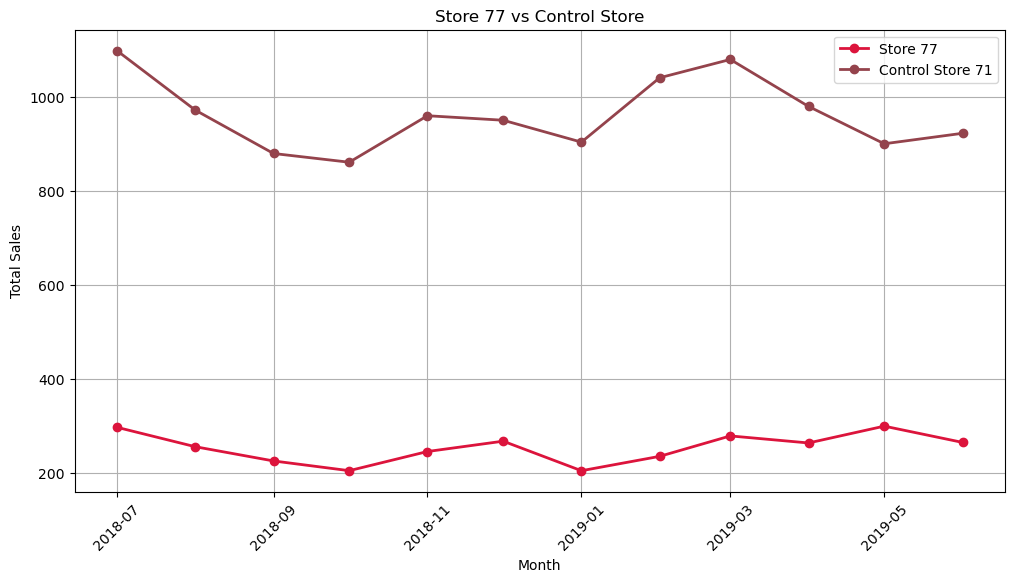

In [194]:
comparison = monthly_metrics[
    monthly_metrics['STORE_NBR'].isin(
        [77, control_store_77]
    )
].copy()

comparison['YEARMONTH_DATE'] = pd.to_datetime(
    comparison['YEARMONTH'].astype(str),
    format='%Y%m'
)

comparison = comparison.sort_values(
    ['STORE_NBR','YEARMONTH_DATE']
)

plt.figure(figsize=(12,6))

temp_77 = comparison[
    comparison['STORE_NBR'] == 77
]

plt.plot(
    temp_77['YEARMONTH_DATE'],
    temp_77['totsales'],
    marker='o',
    color='crimson',
    linewidth=2,
    label='Store 77'
)

temp_control = comparison[
    comparison['STORE_NBR'] == control_store_77
]

plt.plot(
    temp_control['YEARMONTH_DATE'],
    temp_control['totsales'],
    marker='o',
    color='#94434C',
    linewidth=2,
    label=f'Control Store {int(control_store_77)}'
)

plt.title('Store 77 vs Control Store')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

## **Store 86 vs Control Store Sales Comparison**

(array([17713., 17775., 17836., 17897., 17956., 18017.]),
 [Text(17713.0, 0, '2018-07'),
  Text(17775.0, 0, '2018-09'),
  Text(17836.0, 0, '2018-11'),
  Text(17897.0, 0, '2019-01'),
  Text(17956.0, 0, '2019-03'),
  Text(18017.0, 0, '2019-05')])

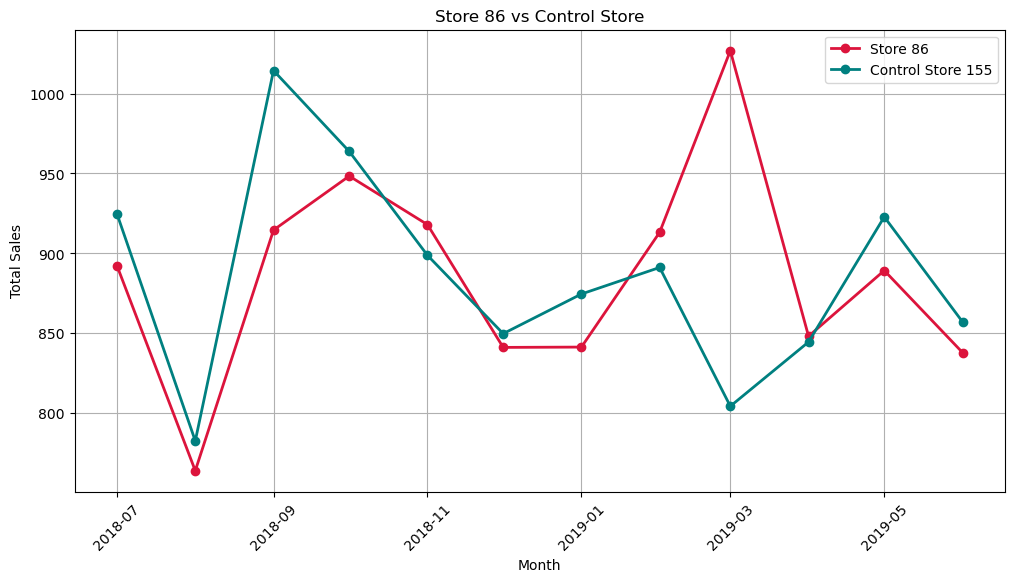

In [195]:
comparison = monthly_metrics[
    monthly_metrics['STORE_NBR'].isin(
        [86, control_store_86]
    )
].copy()

comparison['YEARMONTH_DATE'] = pd.to_datetime(
    comparison['YEARMONTH'].astype(str),
    format='%Y%m'
)

comparison = comparison.sort_values(
    ['STORE_NBR', 'YEARMONTH_DATE']
)

plt.figure(figsize=(12,6))

temp_86 = comparison[
    comparison['STORE_NBR'] == 86
]

plt.plot(
    temp_86['YEARMONTH_DATE'],
    temp_86['totsales'],
    marker='o',
    color='crimson',
    linewidth=2,
    label='Store 86'
)

temp_control = comparison[
    comparison['STORE_NBR'] == control_store_86
]

plt.plot(
    temp_control['YEARMONTH_DATE'],
    temp_control['totsales'],
    marker='o',
    color='teal',
    linewidth=2,
    label=f'Control Store {int(control_store_86)}'
)

plt.title('Store 86 vs Control Store')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

## **Store 88 vs Control Store Sales Comparison**

(array([17713., 17775., 17836., 17897., 17956., 18017.]),
 [Text(17713.0, 0, '2018-07'),
  Text(17775.0, 0, '2018-09'),
  Text(17836.0, 0, '2018-11'),
  Text(17897.0, 0, '2019-01'),
  Text(17956.0, 0, '2019-03'),
  Text(18017.0, 0, '2019-05')])

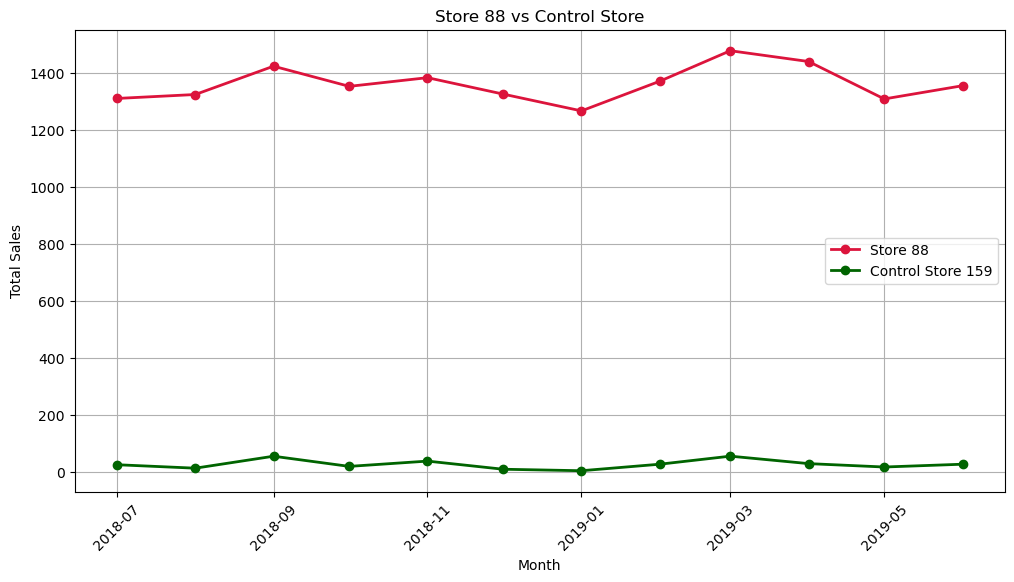

In [196]:
comparison = monthly_metrics[
    monthly_metrics['STORE_NBR'].isin(
        [88, control_store_88]
    )
].copy()

comparison['YEARMONTH_DATE'] = pd.to_datetime(
    comparison['YEARMONTH'].astype(str),
    format='%Y%m'
)

comparison = comparison.sort_values(
    ['STORE_NBR', 'YEARMONTH_DATE']
)

plt.figure(figsize=(12,6))

temp_88 = comparison[
    comparison['STORE_NBR'] == 88
]

plt.plot(
    temp_88['YEARMONTH_DATE'],
    temp_88['totsales'],
    marker='o',
    color='crimson',
    linewidth=2,
    label='Store 88'
)

temp_control = comparison[
    comparison['STORE_NBR'] == control_store_88
]

plt.plot(
    temp_control['YEARMONTH_DATE'],
    temp_control['totsales'],
    marker='o',
    color='darkgreen',
    linewidth=2,
    label=f'Control Store {int(control_store_88)}'
)

plt.title('Store 88 vs Control Store')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

## **Trial Period Analysis**

In [197]:
trial_period = monthly_metrics[
    monthly_metrics['YEARMONTH'] >= 201902
]

trial_period.head()

,STORE_NBR,YEARMONTH,totsales,nCustomers,nTxn,txnPerCust
7,1,201902,225.4,52,55,1.057692
8,1,201903,192.9,45,49,1.088889
9,1,201904,192.9,42,43,1.023810
10,1,201905,221.4,46,51,1.108696
11,1,201906,174.1,42,42,1.000000


## **Statistical significance-Test** 

### *Store-77*

In [198]:
trial_sales_77 = trial_period[
    trial_period['STORE_NBR'] == 77
]['totsales']

control_sales_77 = trial_period[
    trial_period['STORE_NBR'] == control_store_77
]['totsales']

t77, p77 = ttest_ind(
    trial_sales_77,
    control_sales_77
)

print("Store 77")
print("T Statistic:", t77)
print("P Value:", p77)

Store 77
T Statistic: -20.10803615849918
P Value: 3.905023919458683e-08


## **Statistical significance-Test** 

### *Store-86*

In [199]:
trial_sales_86 = trial_period[
    trial_period['STORE_NBR'] == 86
]['totsales']

control_sales_86 = trial_period[
    trial_period['STORE_NBR'] == control_store_86
]['totsales']

t86, p86 = ttest_ind(
    trial_sales_86,
    control_sales_86
)

print("Store 86")
print("T Statistic:", t86)
print("P Value:", p86)

Store 86
T Statistic: 0.9914861460518972
P Value: 0.35048565098844203


## **Statistical significance-Test** 

### *Store-88*

In [200]:
trial_sales_88 = trial_period[
    trial_period['STORE_NBR'] == 88
]['totsales']

control_sales_88 = trial_period[
    trial_period['STORE_NBR'] == control_store_88
]['totsales']

t88, p88 = ttest_ind(
    trial_sales_88,
    control_sales_88
)

print("Store 88")
print("T Statistic:", t88)
print("P Value:", p88)

Store 88
T Statistic: 43.82258405544914
P Value: 8.11212188935107e-11


## **Driver Analysis**

In [201]:
driver_analysis = trial_period.groupby(
    'STORE_NBR'
)[['nCustomers','txnPerCust']].mean()

driver_analysis

,nCustomers,txnPerCust
STORE_NBR,,
1,45.4,1.055817
2,41.4,1.061487
3,105.6,1.167529
4,109.6,1.152393
5,88.2,1.226049
...,...,...
268,43.0,1.045696
269,102.0,1.268652
270,100.0,1.300408


## **Customer Comparison**

In [202]:
customer_comparison = trial_period.groupby(
    'STORE_NBR'
)['nCustomers'].mean().reset_index()

customer_comparison.sort_values(
    'nCustomers',
    ascending=False
).head(10)

,STORE_NBR,nCustomers
221,226,133.6
37,40,128.2
83,88,127.0
160,165,125.2
232,237,122.6
196,201,120.8
88,93,117.8
60,63,116.4
90,95,116.2
194,199,116.0


## **Transaction per Customer Camparison**

In [203]:
txn_comparison = trial_period.groupby(
    'STORE_NBR'
)['txnPerCust'].mean().reset_index()

txn_comparison.sort_values(
    'txnPerCust',
    ascending=False
).head(10)

,STORE_NBR,txnPerCust
123,128,1.340517
174,179,1.334726
179,184,1.328676
11,13,1.322310
40,43,1.321287
186,191,1.320602
100,105,1.318365
95,100,1.308877
191,196,1.308437
147,152,1.302364


## **Sales Lift Calculation**

### *Store-77*

In [204]:
sales_lift_77 = (
    (
        trial_period[trial_period['STORE_NBR']==77]['totsales'].mean()
        -
        trial_period[trial_period['STORE_NBR']==control_store_77]['totsales'].mean()
    )
    /
    trial_period[trial_period['STORE_NBR']==control_store_77]['totsales'].mean()
) * 100

print("Store 77 Sales Lift:", round(sales_lift_77,2), "%")

Store 77 Sales Lift: -72.77 %


## **Sales Lift Calculation**

### *Store-86*

In [205]:
sales_lift_86 = (
    (
        trial_period[trial_period['STORE_NBR']==86]['totsales'].mean()
        -
        trial_period[trial_period['STORE_NBR']==control_store_86]['totsales'].mean()
    )
    /
    trial_period[trial_period['STORE_NBR']==control_store_86]['totsales'].mean()
) * 100

print("Store 86 Sales Lift:", round(sales_lift_86,2), "%")

Store 86 Sales Lift: 4.52 %


## **Sales Lift Calculation**

### *Store-88*

In [206]:
sales_lift_88 = (
    (
        trial_period[trial_period['STORE_NBR']==88]['totsales'].mean()
        -
        trial_period[trial_period['STORE_NBR']==control_store_88]['totsales'].mean()
    )
    /
    trial_period[trial_period['STORE_NBR']==control_store_88]['totsales'].mean()
) * 100

print("Store 88 Sales Lift:", round(sales_lift_88,2), "%")

Store 88 Sales Lift: 4150.55 %


## **Summary Table**

In [207]:
summary = pd.DataFrame({
    'Trial Store':[77,86,88],
    'Control Store':[
        control_store_77,
        control_store_86,
        control_store_88
    ],
    'Sales Lift %':[
        round(sales_lift_77,2),
        round(sales_lift_86,2),
        round(sales_lift_88,2)
    ],
    'P Value':[
        round(p77,4),
        round(p86,4),
        round(p88,4)
    ]
})

summary

,Trial Store,Control Store,Sales Lift %,P Value
0,77,71.0,-72.77,0.0000
1,86,155.0,4.52,0.3505
2,88,159.0,4150.55,0.0000


# **📊 KEY INSIGHTS**

### *Trial stores showed different sales performance compared to their control stores.*

### *Customer numbers had a strong impact on total sales.*

### *Transactions per customer varied across stores.*

### *Transactions per customer varied across stores.*

### *Control stores provided a reliable benchmark for comparison.*

# **💡 RECOMMENDATIONS**

### *Continue successful trial strategies in high-performing stores.*

### *Focus on attracting more customers to increase sales.*

### *Use promotions and loyalty programs to encourage repeat purchases.*

### *Review underperforming stores to identify improvement opportunities.*

### *Continue using data-driven analysis for future business decisions.*